# Наивный байесовский классификатор

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score

In [ ]:
data = datasets.load_breast_cancer()
print(data.DESCR)   

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

In [3]:
X = data.data[:, :2]
y = data.target

In [4]:
df = pd.DataFrame(data.data[:, :2], columns=data.feature_names[:2])
df['target'] = data.target
print(df['target'].value_counts())

target
1    357
0    212
Name: count, dtype: int64


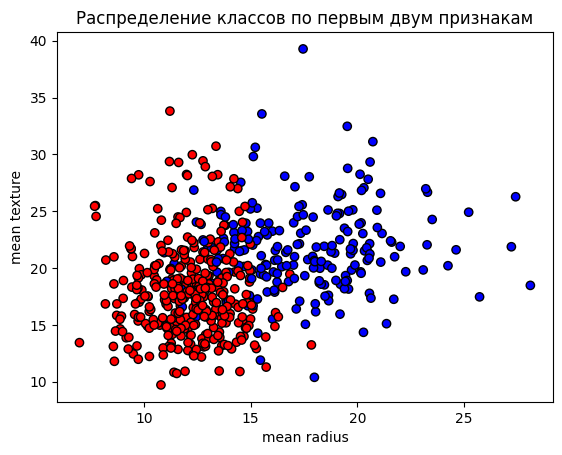

In [5]:
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k')
plt.xlabel(data.feature_names[0])
plt.ylabel(data.feature_names[1])
plt.title('Распределение классов по первым двум признакам')
plt.show()

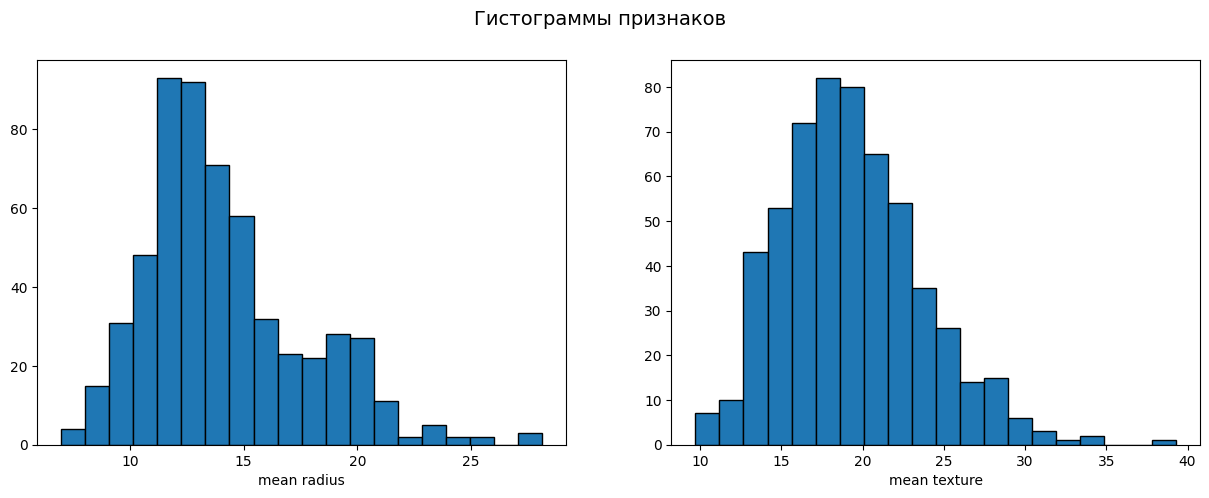

In [6]:
plt.figure(figsize=(15, 5))
for i in range(2):    
    plt.subplot(1, 2, i+1)
    plt.hist(X[:, i], bins=20, edgecolor='black')
    plt.xlabel(data.feature_names[i])
plt.suptitle('Гистограммы признаков', fontsize=14)
plt.show()

In [7]:
gaussian_nb = GaussianNB()
gaussian_nb.fit(X, y)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [8]:
y_pred = gaussian_nb.predict(X)
print("Confusion matrix:\n", confusion_matrix(y, y_pred))
print("Accuracy =", accuracy_score(y, y_pred))
print("F1_score =", f1_score(y, y_pred))

Confusion matrix:
 [[164  48]
 [ 17 340]]
Accuracy = 0.8857644991212654
F1_score = 0.912751677852349


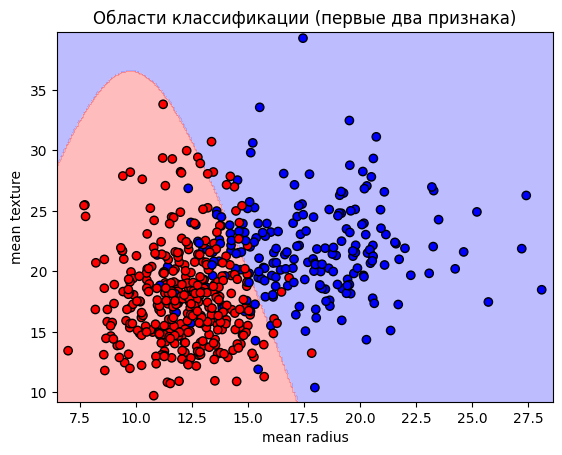

In [9]:
# Создаём сетку
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))
Z = gaussian_nb.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap='bwr')
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k')
plt.xlabel(data.feature_names[0])
plt.ylabel(data.feature_names[1])
plt.title('Области классификации (первые два признака)')
plt.show()

In [10]:
X_full = data.data
y_full = data.target
print("Размерность X_full:", X_full.shape)

Размерность X_full: (569, 30)


In [11]:
gaussian_nb_full = GaussianNB()
gaussian_nb_full.fit(X_full, y_full)
y_pred_full = gaussian_nb_full.predict(X_full)

print("Confusion matrix (все признаки):\n", confusion_matrix(y_full, y_pred_full))
print("Accuracy =", accuracy_score(y_full, y_pred_full))
print("F1_score =", f1_score(y_full, y_pred_full))

Confusion matrix (все признаки):
 [[189  23]
 [ 10 347]]
Accuracy = 0.9420035149384886
F1_score = 0.9546079779917469


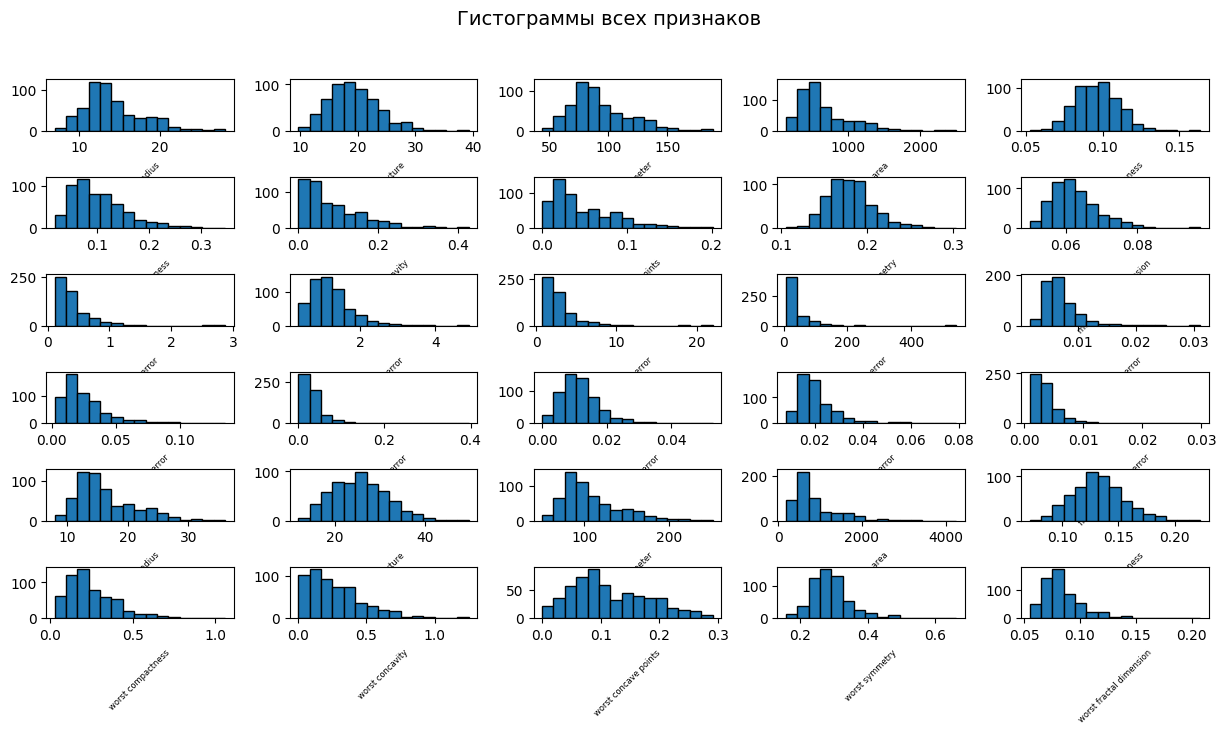

In [12]:
f = plt.figure(figsize=(15, 7))
for i in range(30):
    plt.subplot(6, 5, i+1)
    plt.hist(X_full[:, i], bins=15, edgecolor='black')
    plt.xlabel(data.feature_names[i], rotation=45, fontsize=6)
f.subplots_adjust(hspace=0.9, wspace=0.3)    
plt.suptitle('Гистограммы всех признаков', fontsize=14)
plt.show()

In [14]:
# Создаём DataFrame со всеми признаками
df_all = pd.DataFrame(X_full, columns=data.feature_names)

# Удаляем признаки, которые визуально не похожи на нормальное распределение
# (список взят из методички)
features_to_drop = ['mean concavity', 'radius error', 
                    'perimeter error', 'area error', 
                    'compactness error', 'concavity error',
                    'fractal dimension error', 'worst area', 
                    'worst concavity']

X_selected = df_all.drop(columns=features_to_drop)
print("Оставшиеся признаки:", X_selected.columns.tolist())
print("Размерность:", X_selected.shape)

Оставшиеся признаки: ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'texture error', 'smoothness error', 'concave points error', 'symmetry error', 'worst radius', 'worst texture', 'worst perimeter', 'worst smoothness', 'worst compactness', 'worst concave points', 'worst symmetry', 'worst fractal dimension']
Размерность: (569, 21)


In [15]:
gaussian_nb_selected = GaussianNB()
gaussian_nb_selected.fit(X_selected, y_full)
y_pred_selected = gaussian_nb_selected.predict(X_selected)

print("Confusion matrix (отобранные признаки):\n", confusion_matrix(y_full, y_pred_selected))
print("Accuracy =", accuracy_score(y_full, y_pred_selected))
print("F1_score =", f1_score(y_full, y_pred_selected))

Confusion matrix (отобранные признаки):
 [[196  16]
 [ 15 342]]
Accuracy = 0.945518453427065
F1_score = 0.9566433566433566


In [16]:
print("Сравнение точности:")
print(f"  Первые два признака:       {accuracy_score(y, gaussian_nb.predict(X)):.4f}")
print(f"  Все 30 признаков:          {accuracy_score(y_full, gaussian_nb_full.predict(X_full)):.4f}")
print(f"  Отобранные признаки:       {accuracy_score(y_full, gaussian_nb_selected.predict(X_selected)):.4f}")

Сравнение точности:
  Первые два признака:       0.8858
  Все 30 признаков:          0.9420
  Отобранные признаки:       0.9455


---
## Задание 1: Другие варианты наивного Байеса на Breast Cancer

In [ ]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB, ComplementNB, CategoricalNB
from sklearn.preprocessing import MinMaxScaler, KBinsDiscretizer

# Breast Cancer: X_full уже определён выше
rows = []

# GaussianNB — для непрерывных нормально распределённых данных (наш случай)
m = GaussianNB().fit(X_full, y_full)
rows.append(("GaussianNB",    "непрерывные",      round(accuracy_score(y_full, m.predict(X_full)), 4), "подходит"))

# MultinomialNB — требует неотрицательные целые/частотные данные
X_nn = MinMaxScaler().fit_transform(X_full)   # нормализуем в [0,1]
m = MultinomialNB().fit(X_nn, y_full)
rows.append(("MultinomialNB", "частоты/вероятности", round(accuracy_score(y_full, m.predict(X_nn)), 4),
             "условно (данные не частотные)"))

# BernoulliNB — для бинарных признаков
X_bin = (X_full > X_full.mean(axis=0)).astype(int)   # бинаризация по среднему
m = BernoulliNB().fit(X_bin, y_full)
rows.append(("BernoulliNB",   "бинарные",          round(accuracy_score(y_full, m.predict(X_bin)), 4),
             "слабо (теряем информацию)"))

# ComplementNB — для несбалансированных классов (аналог Multinomial)
m = ComplementNB().fit(X_nn, y_full)
rows.append(("ComplementNB",  "частоты (несбалансированные)", round(accuracy_score(y_full, m.predict(X_nn)), 4),
             "лучше MultinomialNB при дисбалансе"))

# CategoricalNB — для категориальных (дискретных) признаков
X_cat = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='uniform').fit_transform(X_full).astype(int)
m = CategoricalNB().fit(X_cat, y_full)
rows.append(("CategoricalNB", "категориальные",    round(accuracy_score(y_full, m.predict(X_cat)), 4),
             "условно (дискретизация теряет точность)"))

df_nb = pd.DataFrame(rows, columns=["модель", "тип данных", "accuracy", "применимость"])
print(df_nb.to_string(index=False))

## Задание 2: Датасет Titanic — GaussianNB + разные варианты Байеса

In [ ]:
import seaborn as sns

# Загружаем встроенный датасет Titanic (seaborn = Kaggle Titanic)
titanic = sns.load_dataset('titanic')
titanic.head()

In [ ]:
titanic.info()

In [ ]:
# Оставляем только числовые и важные признаки, убираем пропуски
df_t = titanic[['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare']].dropna()

# Кодируем пол
df_t = df_t.copy()
df_t['sex'] = (df_t['sex'] == 'male').astype(int)

y_t  = df_t['survived'].values
X_t  = df_t.drop('survived', axis=1).values

print("Размер выборки:", X_t.shape)

# Гистограммы непрерывных признаков
fig, axes = plt.subplots(2, 3, figsize=(12, 5))
for ax, (col, idx) in zip(axes.ravel(), [('pclass',0),('sex',1),('age',2),('sibsp',3),('parch',4),('fare',5)]):
    ax.hist(X_t[:, idx], bins=20, edgecolor='k')
    ax.set_title(col)
plt.suptitle("Titanic — распределения признаков")
plt.tight_layout(); plt.show()

In [ ]:
# GaussianNB — базовая модель (все признаки непрерывные)
gnb_t = GaussianNB().fit(X_t, y_t)
yp_t  = gnb_t.predict(X_t)
print("GaussianNB:")
print(f"  accuracy={accuracy_score(y_t, yp_t):.4f}  f1={f1_score(y_t, yp_t):.4f}")
print(confusion_matrix(y_t, yp_t))

# BernoulliNB — sex уже бинарный, остальные бинаризуем
X_t_bin = (X_t > X_t.mean(axis=0)).astype(int)
bnb_t = BernoulliNB().fit(X_t_bin, y_t)
yp_tb = bnb_t.predict(X_t_bin)
print("\nBernoulliNB (бинаризованные признаки):")
print(f"  accuracy={accuracy_score(y_t, yp_tb):.4f}  f1={f1_score(y_t, yp_tb):.4f}")

# ComplementNB на нормализованных данных
X_t_nn = MinMaxScaler().fit_transform(X_t)
cnb_t = ComplementNB().fit(X_t_nn, y_t)
yp_tc = cnb_t.predict(X_t_nn)
print("\nComplementNB (нормализованные):")
print(f"  accuracy={accuracy_score(y_t, yp_tc):.4f}  f1={f1_score(y_t, yp_tc):.4f}")

## Задание 3: Titanic с категориальными переменными — CategoricalNB

In [ ]:
# Добавляем категориальные признаки: embarked, class
df_cat = titanic[['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
                  'embarked', 'who', 'alone']].dropna().copy()

# Кодируем строковые категории числами
df_cat['sex']      = (df_cat['sex'] == 'male').astype(int)
df_cat['embarked'] = df_cat['embarked'].map({'S': 0, 'C': 1, 'Q': 2})
df_cat['who']      = df_cat['who'].map({'man': 0, 'woman': 1, 'child': 2})
df_cat['alone']    = df_cat['alone'].astype(int)

print("Признаки:", df_cat.columns.tolist())
print("Размер:", df_cat.shape)

In [ ]:
y_tc3 = df_cat['survived'].values
X_tc3 = df_cat.drop('survived', axis=1).values

# Непрерывные: age, fare → GaussianNB
# Категориальные: pclass, sex, sibsp, parch, embarked, who, alone → CategoricalNB
# Стратегия: обучаем GaussianNB на непрерывных, CategoricalNB — на всём (после дискретизации)

# --- CategoricalNB: все признаки дискретизированы ---
X_disc = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='quantile').fit_transform(X_tc3).astype(int)
cat_nb = CategoricalNB().fit(X_disc, y_tc3)
yp_cat = cat_nb.predict(X_disc)
print("CategoricalNB (дискретизация quantile):")
print(f"  accuracy={accuracy_score(y_tc3, yp_cat):.4f}  f1={f1_score(y_tc3, yp_cat):.4f}")
print(confusion_matrix(y_tc3, yp_cat))

# --- GaussianNB: все признаки как есть ---
gnb3 = GaussianNB().fit(X_tc3, y_tc3)
yp_g3 = gnb3.predict(X_tc3)
print("\nGaussianNB (полный датасет с категориальными):")
print(f"  accuracy={accuracy_score(y_tc3, yp_g3):.4f}  f1={f1_score(y_tc3, yp_g3):.4f}")

In [ ]:
# Итоговая сводка по Titanic
rows_t = [
    ("GaussianNB (числовые)",         round(accuracy_score(y_t,   gnb_t.predict(X_t)),    4)),
    ("BernoulliNB (бинарные)",         round(accuracy_score(y_t,   bnb_t.predict(X_t_bin)),4)),
    ("ComplementNB (нормализованные)", round(accuracy_score(y_t,   cnb_t.predict(X_t_nn)), 4)),
    ("GaussianNB (+ категориальные)",  round(accuracy_score(y_tc3, gnb3.predict(X_tc3)),   4)),
    ("CategoricalNB (дискретизация)",  round(accuracy_score(y_tc3, cat_nb.predict(X_disc)),4)),
]
print(pd.DataFrame(rows_t, columns=["модель", "accuracy"]).to_string(index=False))
# Вывод: GaussianNB — лучший выбор для смешанных данных Titanic;
# CategoricalNB хорош когда признаки действительно категориальные.